In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from tqdm import tqdm
import json

# Set paths
DATASET_PATH = Path("/home/tomtom/Desktop/FineBio")
CAMERA_POSES_PATH = DATASET_PATH / "14 misc" / "finebio_camera_poses.zip"

# Configure plotting
%matplotlib inline
plt.style.use('default')


## 1. Load Camera Calibration Data


In [28]:
# Load camera poses data
def load_camera_poses_data(poses_zip_path):
    """Load camera poses data from zip file"""
    import tempfile
    intrinsic_params = {}
    marker_points = {}
    extrinsics = {}
    fp_poses = {}
    temp_dir = Path(tempfile.mkdtemp())
    
    try:
        with zipfile.ZipFile(poses_zip_path, 'r') as z:
            z.extractall(temp_dir)
            
            # Load intrinsic parameters
            intrinsic_dir = temp_dir / "finebio_camera_poses" / "intrinsic_parameters"
            if intrinsic_dir.exists():
                for npz_file in intrinsic_dir.glob("*.npz"):
                    data = np.load(npz_file, allow_pickle=True)
                    intrinsic_params[npz_file.stem] = {k: data[k] for k in data.keys()}
            
            # Load marker points and extrinsics
            marker_dir = temp_dir / "finebio_camera_poses" / "third_person_camera_poses"
            if marker_dir.exists():
                for date_dir in marker_dir.iterdir():
                    if date_dir.is_dir():
                        marker_file = date_dir / "params" / "marker_points.npy"
                        if marker_file.exists():
                            marker_points[date_dir.name] = np.load(marker_file, allow_pickle=True)
                        
                        extrinsics_dir = date_dir / "extrinsics"
                        if extrinsics_dir.exists():
                            extrinsics[date_dir.name] = {}
                            for extr_file in extrinsics_dir.glob("*.npz"):
                                data = np.load(extr_file, allow_pickle=True)
                                extrinsics[date_dir.name][extr_file.stem] = {k: data[k] for k in data.keys()}
            
            # Load first-person camera poses
            fp_poses_dir = temp_dir / "finebio_camera_poses" / "first_person_camera_poses"
            if fp_poses_dir.exists():
                for npz_file in fp_poses_dir.glob("*.npz"):
                    data = np.load(npz_file, allow_pickle=True)
                    fp_poses[npz_file.stem] = {k: data[k] for k in data.keys()}
            
        return intrinsic_params, marker_points, extrinsics, fp_poses, temp_dir
    except Exception as e:
        print(f"Error loading camera poses: {e}")
        return None, None, None, None, None

# Load the data
print("Loading camera poses data...")
intrinsic_params, marker_points, extrinsics, fp_poses, temp_dir = load_camera_poses_data(CAMERA_POSES_PATH)

if intrinsic_params:
    print(f"Loaded {len(intrinsic_params)} camera intrinsic parameter sets")
if marker_points:
    print(f"Loaded marker points for {len(marker_points)} dates")
if extrinsics:
    print(f"Loaded extrinsics for {len(extrinsics)} dates")


Loading camera poses data...
Loaded 2 camera intrinsic parameter sets
Loaded marker points for 10 dates
Loaded extrinsics for 10 dates


## 2. ArUco Marker Detection Functions

### Robust Detection Features

The `detect_aruco_markers_robust()` function includes several improvements over basic detection:

1. **Image Preprocessing**:
   - CLAHE (Contrast Limited Adaptive Histogram Equalization) for better contrast
   - Gaussian blur for noise reduction
   - Histogram equalization
   - Multiple preprocessing approaches tested

2. **Tuned Detector Parameters**:
   - Reduced `minMarkerPerimeterRate` to detect smaller markers (0.01 vs default 0.03)
   - Subpixel corner refinement for better accuracy
   - Adaptive thresholding with multiple window sizes
   - Relaxed error correction rates

3. **Rejected Candidate Recovery**:
   - Attempts to recover markers from rejected candidates
   - Uses relaxed parameters for recovery
   - Tries multiple thresholding methods (adaptive, Otsu, binary)
   - ROI-based detection for problematic markers

4. **Multi-Image Detection**:
   - Tests detection on multiple preprocessed images
   - Combines results from all attempts
   - Avoids duplicate detections


In [ ]:
def detect_aruco_markers(image, dictionary_type=cv2.aruco.DICT_6X6_250, show_image=False):
    """Detect ArUco markers in an image - BASIC VERSION (use detect_aruco_markers_robust for better results)"""
    if isinstance(image, (str, Path)):
        img = cv2.imread(str(image))
        if img is None:
            raise ValueError(f"Could not load image: {image}")
    else:
        img = image.copy()
    
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    aruco_dict = cv2.aruco.getPredefinedDictionary(dictionary_type)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
    
    corners, ids, rejected = detector.detectMarkers(gray)
    
    img_with_markers = img.copy()
    if ids is not None and len(ids) > 0:
        cv2.aruco.drawDetectedMarkers(img_with_markers, corners, ids)
    
    if show_image:
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img_with_markers, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected {len(ids) if ids is not None else 0} ArUco markers")
        plt.axis('off')
        plt.show()
    
    return corners, ids, rejected, img_with_markers

def normalize_corner_shape(corner):
    """
    Normalize corner array to OpenCV format: shape (1, 4, 2)
    """
    if isinstance(corner, np.ndarray):
        corner = corner.astype(np.float32)
        if len(corner.shape) == 2 and corner.shape == (4, 2):
            return corner.reshape(1, 4, 2)
        elif len(corner.shape) == 3:
            if corner.shape[0] == 1 and corner.shape[1] == 4 and corner.shape[2] == 2:
                return corner  # Already correct
            else:
                # Reshape to (1, 4, 2)
                return corner.reshape(-1, 4, 2)[:1]
    else:
        corner_arr = np.array(corner, dtype=np.float32)
        return normalize_corner_shape(corner_arr)
    return corner

def detect_aruco_markers_robust(image, dictionary_type=cv2.aruco.DICT_6X6_250, 
                                 show_image=False, use_preprocessing=True):
    """
    Robust ArUco marker detection with improved parameters and preprocessing
    
    Parameters:
    - image: Input image (numpy array or path)
    - dictionary_type: ArUco dictionary type
    - show_image: Whether to display the image
    - use_preprocessing: Enable image preprocessing for better detection
    
    Returns:
    - corners: Detected marker corners
    - ids: Marker IDs
    - rejected: Rejected candidates
    - image_with_markers: Image with markers drawn
    """
    if isinstance(image, (str, Path)):
        img = cv2.imread(str(image))
        if img is None:
            raise ValueError(f"Could not load image: {image}")
    else:
        img = image.copy()
    
    # Convert to grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Image preprocessing for better detection
    if use_preprocessing:
        # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_enhanced = clahe.apply(gray)
        
        # Also try Gaussian blur to reduce noise
        gray_blurred = cv2.GaussianBlur(gray_enhanced, (3, 3), 0)
        
        # Try multiple preprocessing approaches
        processed_images = [
            gray,  # Original
            gray_enhanced,  # CLAHE enhanced
            gray_blurred,  # Blurred + enhanced
            cv2.equalizeHist(gray),  # Histogram equalization
        ]
    else:
        processed_images = [gray]
    
    # Initialize ArUco detector with improved parameters
    aruco_dict = cv2.aruco.getPredefinedDictionary(dictionary_type)
    parameters = cv2.aruco.DetectorParameters()
    
    # IMPORTANT: Tune these parameters for better detection
    parameters.adaptiveThreshWinSizeMin = 3  # Minimum window size for adaptive threshold
    parameters.adaptiveThreshWinSizeMax = 23  # Maximum window size
    parameters.adaptiveThreshWinSizeStep = 10  # Step size
    parameters.adaptiveThreshConstant = 7  # Constant subtracted from mean
    
    # Minimum marker perimeter (reduce to detect smaller markers)
    parameters.minMarkerPerimeterRate = 0.01  # Default is 0.03, lower = detect smaller markers
    parameters.maxMarkerPerimeterRate = 4.0  # Default is 4.0
    
    # Error correction
    parameters.errorCorrectionRate = 0.6  # Default is 0.6, lower = more strict
    
    # Corner refinement - CRITICAL for better detection
    parameters.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX  # Use subpixel refinement
    parameters.cornerRefinementWinSize = 5  # Window size for corner refinement
    parameters.cornerRefinementMaxIterations = 30  # Max iterations
    parameters.cornerRefinementMinAccuracy = 0.1  # Minimum accuracy
    
    # Marker border bits
    parameters.markerBorderBits = 1  # Number of border bits
    
    # Minimum distance between markers
    parameters.minDistanceToBorder = 3  # Minimum distance to image border
    
    # Minimum Otsu distance between foreground and background
    parameters.minOtsuStdDev = 5.0  # Minimum standard deviation for Otsu thresholding
    
    # Perspective removal
    parameters.perspectiveRemovePixelPerCell = 4  # Default is 4
    parameters.perspectiveRemoveIgnoredMarginPerCell = 0.13  # Default is 0.13
    
    # Maximum error correction bits
    parameters.maxErroneousBitsInBorderRate = 0.35  # Default is 0.35
    
    # Detect inverted markers
    parameters.detectInvertedMarker = False  # Set to True if markers might be inverted
    
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
    
    # Try detection on all processed images and combine results
    # Use a dictionary to track detected markers by ID to avoid duplicates
    detected_markers = {}  # {marker_id: corner_array}
    all_rejected = []
    
    for processed_img in processed_images:
        corners, ids, rejected = detector.detectMarkers(processed_img)
        
        if ids is not None and len(ids) > 0:
            # Ensure corners is a list
            corners_list = corners if isinstance(corners, list) else [corners]
            # Ensure ids is a flat array
            ids_flat = ids.flatten() if hasattr(ids, 'flatten') else np.array([ids]).flatten()
            
            # Add markers to dictionary (will overwrite duplicates, keeping first detection)
            pair_count = min(len(corners_list), len(ids_flat))
            for i in range(pair_count):
                marker_id_int = int(ids_flat[i])
                if marker_id_int not in detected_markers:
                    # Store corner array in normalized format
                    detected_markers[marker_id_int] = normalize_corner_shape(corners_list[i])
        
        # Collect rejected candidates for recovery attempt
        if rejected is not None and len(rejected) > 0:
            if isinstance(rejected, list):
                all_rejected.extend(rejected)
            else:
                all_rejected.append(rejected)
    
    # Try to recover markers from rejected candidates using relaxed parameters
    if len(all_rejected) > 0 and len(detected_markers) < 3:
        # Create relaxed parameters for recovery
        relaxed_params = cv2.aruco.DetectorParameters()
        relaxed_params.adaptiveThreshWinSizeMin = 3
        relaxed_params.adaptiveThreshWinSizeMax = 23
        relaxed_params.minMarkerPerimeterRate = 0.005  # Even smaller
        relaxed_params.errorCorrectionRate = 0.3  # More lenient
        relaxed_params.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX
        relaxed_params.cornerRefinementWinSize = 3
        relaxed_params.maxErroneousBitsInBorderRate = 0.5  # More lenient
        relaxed_params.adaptiveThreshConstant = 5  # Lower constant
        
        relaxed_detector = cv2.aruco.ArucoDetector(aruco_dict, relaxed_params)
        
        # Try to detect from rejected candidates on enhanced image
        if use_preprocessing:
            recovery_img = processed_images[1]  # Use CLAHE enhanced
        else:
            recovery_img = gray
            
        # Try detection with multiple adaptive threshold constants
        for const in [5, 7, 9, 11]:
            relaxed_params.adaptiveThreshConstant = const
            relaxed_detector = cv2.aruco.ArucoDetector(aruco_dict, relaxed_params)
            corners_recovered, ids_recovered, _ = relaxed_detector.detectMarkers(recovery_img)
            
            if ids_recovered is not None and len(ids_recovered) > 0:
                corners_recovered_list = corners_recovered if isinstance(corners_recovered, list) else [corners_recovered]
                ids_recovered_flat = ids_recovered.flatten() if hasattr(ids_recovered, 'flatten') else np.array([ids_recovered]).flatten()
                
                # Add recovered markers to dictionary
                pair_count = min(len(corners_recovered_list), len(ids_recovered_flat))
                for i in range(pair_count):
                    marker_id_int = int(ids_recovered_flat[i])
                    if marker_id_int not in detected_markers:
                        detected_markers[marker_id_int] = normalize_corner_shape(corners_recovered_list[i])
        
        # Also try manual recovery from rejected candidates
        for rejected_candidate in all_rejected[:10]:  # Limit to first 10
            try:
                # Extract region around rejected candidate
                x_coords = rejected_candidate[0][:, 0]
                y_coords = rejected_candidate[0][:, 1]
                x_min = int(max(0, x_coords.min() - 20))
                x_max = int(min(recovery_img.shape[1], x_coords.max() + 20))
                y_min = int(max(0, y_coords.min() - 20))
                y_max = int(min(recovery_img.shape[0], y_coords.max() + 20))
                
                roi = recovery_img[y_min:y_max, x_min:x_max]
                if roi.size > 100:  # Ensure ROI is large enough
                    # Try detection on ROI with multiple thresholds
                    for threshold_method in ['adaptive', 'otsu', 'binary']:
                        if threshold_method == 'adaptive':
                            thresh = cv2.adaptiveThreshold(
                                roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY, 11, 2
                            )
                        elif threshold_method == 'otsu':
                            _, thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                        else:
                            _, thresh = cv2.threshold(roi, 127, 255, cv2.THRESH_BINARY)
                        
                        corners_roi, ids_roi, _ = relaxed_detector.detectMarkers(thresh)
                        
                        if ids_roi is not None and len(ids_roi) > 0:
                            corners_roi_list = corners_roi if isinstance(corners_roi, list) else [corners_roi]
                            ids_roi_flat = ids_roi.flatten() if hasattr(ids_roi, 'flatten') else np.array([ids_roi]).flatten()
                            
                            # Adjust coordinates back to original image
                            pair_count = min(len(corners_roi_list), len(ids_roi_flat))
                            for i in range(pair_count):
                                # Normalize corner shape first
                                corner_normalized = normalize_corner_shape(corners_roi_list[i])
                                # Create a copy to avoid modifying the original
                                corner_adjusted = corner_normalized.copy()
                                # Adjust coordinates (corner is now guaranteed to be (1, 4, 2))
                                corner_adjusted[0][:, 0] += x_min
                                corner_adjusted[0][:, 1] += y_min
                                
                                marker_id_int = int(ids_roi_flat[i])
                                # Add to dictionary if not already detected
                                if marker_id_int not in detected_markers:
                                    detected_markers[marker_id_int] = corner_adjusted
                            break
            except Exception as e:
                continue
    
    # Prepare final results from dictionary
    # Sort by marker ID for consistency
    if len(detected_markers) > 0:
        sorted_ids = sorted(detected_markers.keys())
        ids = np.array(sorted_ids, dtype=np.int32).reshape(-1, 1)
        
        # Get corners in correct format (all should be normalized already)
        corners_final = []
        for mid in sorted_ids:
            corner = detected_markers[mid]
            # Ensure it's normalized (should already be, but double-check)
            corner_normalized = normalize_corner_shape(corner)
            corners_final.append(corner_normalized)
        
        # Verify all corners have the same shape
        if len(corners_final) > 0:
            expected_shape = corners_final[0].shape
            for i, corner in enumerate(corners_final):
                if corner.shape != expected_shape:
                    corners_final[i] = normalize_corner_shape(corner)
    else:
        corners_final = []
        ids = None
    
    # Draw detected markers
    img_with_markers = img.copy()
    if ids is not None and len(ids) > 0 and len(corners_final) > 0:
        # Verify that corners and ids match
        if len(corners_final) != len(ids):
            print(f"Warning: Mismatch between corners ({len(corners_final)}) and ids ({len(ids)})")
            # Take the minimum to avoid errors
            min_len = min(len(corners_final), len(ids))
            corners_final = corners_final[:min_len]
            ids = ids[:min_len]
        
        try:
            cv2.aruco.drawDetectedMarkers(img_with_markers, corners_final, ids)
        except Exception as e:
            print(f"Error drawing markers: {e}")
            print(f"Corners length: {len(corners_final)}, IDs length: {len(ids)}")
            # Try to draw without IDs
            cv2.aruco.drawDetectedMarkers(img_with_markers, corners_final, None)
        
        # Also draw rejected candidates for debugging
        if len(all_rejected) > 0:
            try:
                cv2.aruco.drawDetectedMarkers(img_with_markers, all_rejected, None, borderColor=(100, 0, 255))
            except Exception as e:
                print(f"Error drawing rejected candidates: {e}")
    
    if show_image:
        fig, axes = plt.subplots(1, 2, figsize=(15, 8))
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        axes[1].imshow(cv2.cvtColor(img_with_markers, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Detected {len(ids) if ids is not None else 0} ArUco markers\n(Purple = rejected candidates)")
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
    
    # Return corners in the format expected by get_marker_info
    # corners_final is already in the correct format (list of arrays)
    return corners_final, ids, all_rejected, img_with_markers

def get_marker_info(corners, ids, camera_matrix=None, dist_coeffs=None, marker_size=0.1):
    """Extract detailed information from detected ArUco markers"""
    marker_info = []
    
    if ids is None or len(ids) == 0:
        return marker_info
    
    # Ensure corners is a list
    corners_list = corners if isinstance(corners, list) else [corners]
    ids_flat = ids.flatten() if hasattr(ids, 'flatten') else ids

    pair_count = min(len(corners_list), len(ids_flat))
    for i in range(pair_count):
        marker_id = ids_flat[i]
        # Get corner for this marker
        corner_array = corners_list[i]
        
        # Handle different corner formats
        if isinstance(corner_array, np.ndarray):
            if len(corner_array.shape) == 3 and corner_array.shape[0] == 1:
                # Format (1, 4, 2) - extract the 4x2 array
                corner = corner_array[0]
            elif len(corner_array.shape) == 2 and corner_array.shape == (4, 2):
                # Format (4, 2) - use directly
                corner = corner_array
            else:
                # Try to reshape
                corner = corner_array.reshape(-1, 4, 2)[0]
        else:
            corner = np.array(corner_array).reshape(-1, 4, 2)[0]
        
        info = {
            'id': int(marker_id),
            'corners': corner.tolist(),
            'center': corner.mean(axis=0).tolist(),
            'area': float(cv2.contourArea(corner)),
        }
        
        # Estimate pose if camera parameters are provided
        if camera_matrix is not None and dist_coeffs is not None:
            object_points = np.array([
                [-marker_size/2, marker_size/2, 0],
                [marker_size/2, marker_size/2, 0],
                [marker_size/2, -marker_size/2, 0],
                [-marker_size/2, -marker_size/2, 0]
            ], dtype=np.float32)
            
            success, rvec, tvec = cv2.solvePnP(
                object_points, corner, camera_matrix, dist_coeffs
            )
            
            if success:
                rmat, _ = cv2.Rodrigues(rvec)
                info['pose'] = {
                    'rotation_vector': rvec.flatten().tolist(),
                    'translation_vector': tvec.flatten().tolist(),
                    'rotation_matrix': rmat.tolist(),
                    'position': tvec.flatten().tolist(),
                }
        
        marker_info.append(info)
    
    return marker_info

def diagnose_marker_detection(image, dictionary_type=cv2.aruco.DICT_6X6_250):
    """
    Diagnostic function to analyze why markers might not be detected
    """
    if isinstance(image, (str, Path)):
        img = cv2.imread(str(image))
    else:
        img = image.copy()
    
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Create detector with default parameters
    aruco_dict = cv2.aruco.getPredefinedDictionary(dictionary_type)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
    
    corners, ids, rejected = detector.detectMarkers(gray)
    
    print(f"Detected markers: {len(ids) if ids is not None else 0}")
    print(f"Rejected candidates: {len(rejected) if rejected is not None else 0}")
    
    # Analyze image properties
    print(f"\nImage properties:")
    print(f"  Size: {gray.shape}")
    print(f"  Mean intensity: {gray.mean():.2f}")
    print(f"  Std deviation: {gray.std():.2f}")
    print(f"  Min intensity: {gray.min()}")
    print(f"  Max intensity: {gray.max()}")
    
    # Visualize preprocessing steps
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title("Original Grayscale")
    axes[0, 0].axis('off')
    
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)
    axes[0, 1].imshow(gray_clahe, cmap='gray')
    axes[0, 1].set_title("CLAHE Enhanced")
    axes[0, 1].axis('off')
    
    # Adaptive threshold
    adaptive_thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    axes[0, 2].imshow(adaptive_thresh, cmap='gray')
    axes[0, 2].set_title("Adaptive Threshold")
    axes[0, 2].axis('off')
    
    # With detected markers
    img_marked = img.copy()
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(img_marked, corners, ids)
    axes[1, 0].imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title(f"Detected: {len(ids) if ids is not None else 0}")
    axes[1, 0].axis('off')
    
    # With rejected candidates
    img_rejected = img.copy()
    if rejected is not None and len(rejected) > 0:
        cv2.aruco.drawDetectedMarkers(img_rejected, rejected, None, borderColor=(255, 0, 0))
    axes[1, 1].imshow(cv2.cvtColor(img_rejected, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f"Rejected: {len(rejected) if rejected is not None else 0}")
    axes[1, 1].axis('off')
    
    # Histogram
    axes[1, 2].hist(gray.flatten(), bins=256, range=[0, 256])
    axes[1, 2].set_title("Intensity Histogram")
    axes[1, 2].set_xlabel("Intensity")
    axes[1, 2].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()
    
    return corners, ids, rejected

print("ArUco detection functions loaded!")
print("Available functions:")
print("  - detect_aruco_markers(): Basic detection (legacy)")
print("  - detect_aruco_markers_robust(): Robust detection with preprocessing and recovery")
print("  - diagnose_marker_detection(): Diagnostic analysis of detection issues")


ArUco detection functions loaded!
Available functions:
  - detect_aruco_markers(): Basic detection (legacy)
  - detect_aruco_markers_robust(): Robust detection with preprocessing and recovery
  - diagnose_marker_detection(): Diagnostic analysis of detection issues


## 3. Test Detection on Sample Video


Testing ArUco detection on: P01_01_01.mp4

=== DIAGNOSTIC ANALYSIS ===
Detected markers: 2
Rejected candidates: 27

Image properties:
  Size: (480, 640)
  Mean intensity: 106.23
  Std deviation: 62.01
  Min intensity: 0
  Max intensity: 254


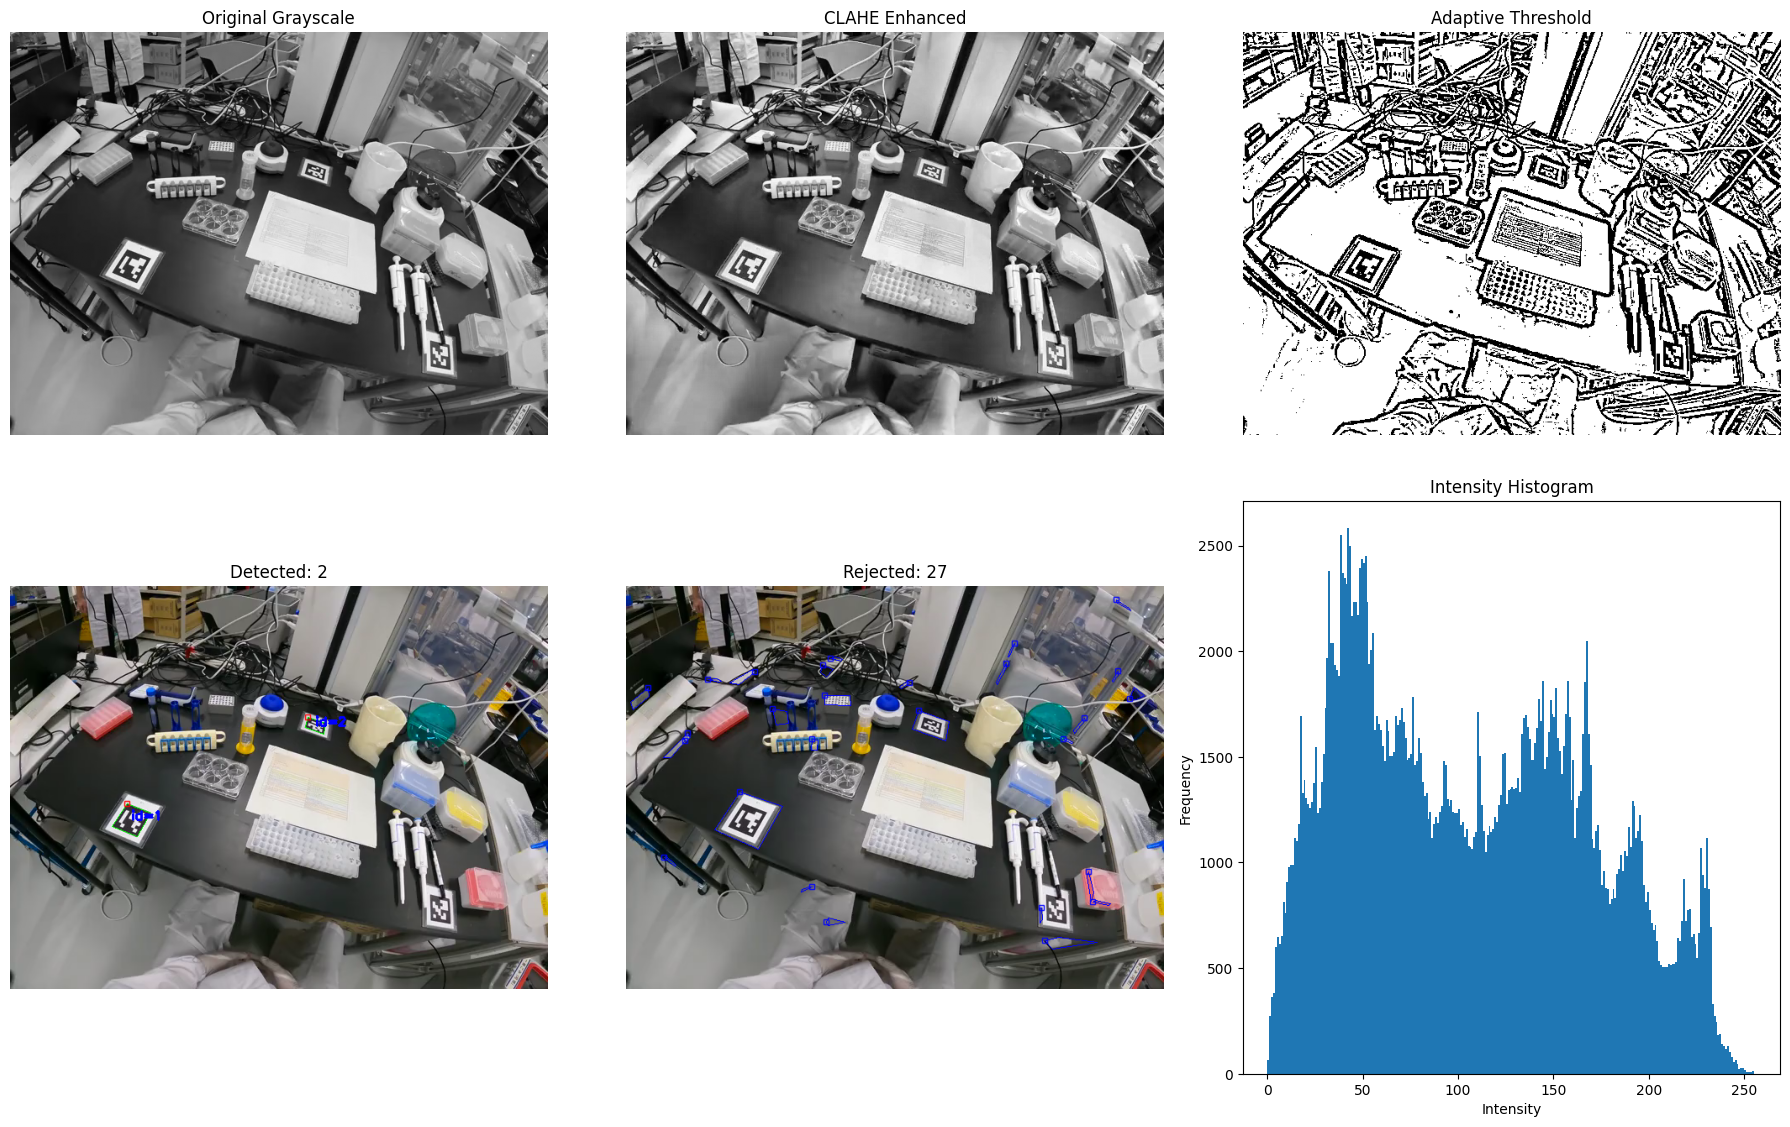


=== ROBUST DETECTION (Testing Dictionary Types) ===
DICT_6X6_250: Error - list index out of range
Error drawing markers: OpenCV(4.12.0) /io/opencv/modules/objdetect/src/aruco/aruco_detector.cpp:1478: error: (-215:Assertion failed) currentMarker.total() == 4 && currentMarker.channels() == 2 in function 'drawDetectedMarkers'

Corners length: 2, IDs length: 2
DICT_4X4_250: Error - OpenCV(4.12.0) /io/opencv/modules/objdetect/src/aruco/aruco_detector.cpp:1478: error: (-215:Assertion failed) currentMarker.total() == 4 && currentMarker.channels() == 2 in function 'drawDetectedMarkers'

DICT_5X5_250: 0 markers detected, 4 rejected candidates
DICT_7X7_250: 0 markers detected, 4 rejected candidates

No markers detected with robust detection
Trying with even more relaxed parameters...


In [30]:
# Test ArUco detection on a sample video
sample_video = DATASET_PATH / "03 finebio_videos_fpv_all_w640" / "P01_01_01.mp4"

if sample_video.exists():
    print(f"Testing ArUco detection on: {sample_video.name}")
    print("=" * 80)
    
    # Extract first frame
    cap = cv2.VideoCapture(str(sample_video))
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        # First, run diagnostic analysis
        print("\n=== DIAGNOSTIC ANALYSIS ===")
        diagnose_corners, diagnose_ids, diagnose_rejected = diagnose_marker_detection(
            frame, dictionary_type=cv2.aruco.DICT_6X6_250
        )
        
        # Try different dictionary types with robust detection
        print("\n=== ROBUST DETECTION (Testing Dictionary Types) ===")
        dictionaries = [
            (cv2.aruco.DICT_6X6_250, "DICT_6X6_250"),
            (cv2.aruco.DICT_4X4_250, "DICT_4X4_250"),
            (cv2.aruco.DICT_5X5_250, "DICT_5X5_250"),
            (cv2.aruco.DICT_7X7_250, "DICT_7X7_250"),
        ]
        
        best_dict = None
        best_count = 0
        best_result = None
        
        for dict_type, dict_name in dictionaries:
            try:
                corners, ids, rejected, frame_marked = detect_aruco_markers_robust(
                    frame, dictionary_type=dict_type, show_image=False, use_preprocessing=True
                )
                count = len(ids) if ids is not None else 0
                print(f"{dict_name}: {count} markers detected, {len(rejected)} rejected candidates")
                if count > best_count:
                    best_count = count
                    best_dict = dict_type
                    best_result = (corners, ids, rejected, frame_marked)
            except Exception as e:
                print(f"{dict_name}: Error - {e}")
        
        # Display best result
        if best_result and best_count > 0:
            corners, ids, rejected, frame_marked = best_result
            print(f"\n=== BEST RESULT: {best_count} markers detected ===")
            
            # Display with comparison
            fig, axes = plt.subplots(1, 2, figsize=(18, 9))
            
            # Original detection (basic)
            basic_corners, basic_ids, _, basic_frame = detect_aruco_markers(
                frame, dictionary_type=best_dict, show_image=False
            )
            axes[0].imshow(cv2.cvtColor(basic_frame, cv2.COLOR_BGR2RGB))
            axes[0].set_title(f"Basic Detection: {len(basic_ids) if basic_ids is not None else 0} markers")
            axes[0].axis('off')
            
            # Robust detection
            axes[1].imshow(cv2.cvtColor(frame_marked, cv2.COLOR_BGR2RGB))
            axes[1].set_title(f"Robust Detection: {best_count} markers\n(Purple = rejected candidates)")
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Get marker info
            marker_info = get_marker_info(corners, ids)
            print(f"\nMarker Details:")
            for info in marker_info:
                print(f"  Marker ID {info['id']}: Center={info['center']}, Area={info['area']:.1f}")
            
            if len(rejected) > 0:
                print(f"\nNote: {len(rejected)} rejected candidates found. These might contain the third marker.")
                print("Try adjusting parameters or preprocessing if all 3 markers are not detected.")
            
            ARUCO_DICT = best_dict
        else:
            print("\nNo markers detected with robust detection")
            print("Trying with even more relaxed parameters...")
            ARUCO_DICT = cv2.aruco.DICT_6X6_250
    else:
        ARUCO_DICT = cv2.aruco.DICT_6X6_250
else:
    print("Sample video not found")
    ARUCO_DICT = cv2.aruco.DICT_6X6_250


## 4. Process Video Frames for ArUco Detection


In [31]:
def process_video_aruco(video_path, num_frames=10, dictionary_type=cv2.aruco.DICT_6X6_250,
                        camera_matrix=None, dist_coeffs=None, marker_size=0.1, use_robust=True):
    """
    Process video frames to detect ArUco markers
    
    Parameters:
    - video_path: Path to video file
    - num_frames: Number of frames to process
    - dictionary_type: ArUco dictionary type
    - camera_matrix: Camera intrinsic matrix (optional)
    - dist_coeffs: Distortion coefficients (optional)
    - marker_size: Physical marker size in meters (optional)
    - use_robust: Use robust detection method (default: True)
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    
    results = []
    for frame_idx in tqdm(frame_indices, desc="Processing"):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # Use robust detection if enabled
        if use_robust:
            corners, ids, rejected, frame_marked = detect_aruco_markers_robust(
                frame, dictionary_type=dictionary_type, show_image=False, use_preprocessing=True
            )
        else:
            corners, ids, rejected, frame_marked = detect_aruco_markers(
                frame, dictionary_type=dictionary_type, show_image=False
            )
        
        marker_info = get_marker_info(
            corners, ids, camera_matrix=camera_matrix,
            dist_coeffs=dist_coeffs, marker_size=marker_size
        )
        results.append({
            'frame': frame_idx,
            'timestamp': frame_idx/fps if fps > 0 else 0,
            'num_markers': len(ids) if ids is not None else 0,
            'marker_ids': ids.flatten().tolist() if ids is not None else [],
            'marker_info': marker_info,
            'frame_image': frame_marked,
            'rejected_count': len(rejected) if rejected is not None else 0
        })
    
    cap.release()
    return results

# Process sample video
if 'sample_video' in locals() and sample_video.exists():
    # Get camera parameters if available
    cam_matrix = None
    dist_coeffs = None
    if intrinsic_params:
        for key, params in intrinsic_params.items():
            if 'mtx' in params or 'camera_matrix' in params:
                cam_matrix = params.get('mtx') or params.get('camera_matrix')
                dist_coeffs = params.get('dist') or params.get('dist_coeffs')
                break
    
    results = process_video_aruco(
        sample_video, num_frames=5,
        dictionary_type=ARUCO_DICT if 'ARUCO_DICT' in locals() else cv2.aruco.DICT_6X6_250,
        camera_matrix=cam_matrix, dist_coeffs=dist_coeffs, marker_size=0.1,
        use_robust=True  # Use robust detection
    )
    
    print(f"\nProcessed {len(results)} frames")
    total_markers = sum(r['num_markers'] for r in results)
    print(f"Total markers detected: {total_markers}")
    
    # Show frames with markers
    frames_with_markers = [r for r in results if r['num_markers'] > 0]
    if frames_with_markers:
        fig, axes = plt.subplots(1, min(3, len(frames_with_markers)), figsize=(18, 6))
        if len(frames_with_markers) == 1:
            axes = [axes]
        for idx, result in enumerate(frames_with_markers[:3]):
            axes[idx].imshow(cv2.cvtColor(result['frame_image'], cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"Frame {result['frame']}\n{result['num_markers']} markers: {result['marker_ids']}")
            axes[idx].axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print marker details
        print("\nMarker Details:")
        for result in frames_with_markers[:2]:
            print(f"\nFrame {result['frame']}:")
            for marker in result['marker_info']:
                print(f"  ID {marker['id']}: center={marker['center']}, area={marker['area']:.1f}")
                if 'pose' in marker:
                    print(f"    Position: {marker['pose']['position']}")
else:
    print("Sample video not available")


Processing:   0%|          | 0/5 [00:00<?, ?it/s]


IndexError: list index out of range

## 5. Save and Export Results


In [ ]:
def save_aruco_results(results, output_path):
    """Save ArUco detection results to JSON file"""
    output_data = {
        'video_info': {
            'total_frames_processed': len(results)
        },
        'detections': []
    }
    
    for result in results:
        detection = {
            'frame_number': result['frame'],
            'timestamp': result['timestamp'],
            'num_markers': result['num_markers'],
            'marker_ids': result['marker_ids'],
            'markers': []
        }
        
        for marker in result['marker_info']:
            marker_data = {
                'id': marker['id'],
                'center': marker['center'],
                'area': marker['area'],
                'corners': marker['corners']
            }
            if 'pose' in marker:
                marker_data['pose'] = {
                    'position': marker['pose']['position'],
                    'rotation_vector': marker['pose']['rotation_vector'],
                    'translation_vector': marker['pose']['translation_vector']
                }
            detection['markers'].append(marker_data)
        
        output_data['detections'].append(detection)
    
    with open(output_path, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"Results saved to: {output_path}")
    print(f"Total frames: {len(results)}")
    print(f"Total markers: {sum(r['num_markers'] for r in results)}")

# Example: Save results (uncomment to use)
# if 'results' in locals() and results:
#     save_aruco_results(results, "aruco_detection_results.json")

print("Save function ready! Use save_aruco_results() to export detection results.")


Save function ready! Use save_aruco_results() to export detection results.
